## 1. Setup and Imports

In [2]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image, ImageDraw, ImageFont
import cv2
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pillow version: {Image.__version__}")

# Create output directories
os.makedirs('../results/detections', exist_ok=True)
os.makedirs('../results/analysis', exist_ok=True)
os.makedirs('../data', exist_ok=True)
print("\n✓ Output directories ready")

✓ All libraries imported successfully!
NumPy version: 2.3.4
OpenCV version: 4.12.0
Pillow version: 12.0.0

✓ Output directories ready


## 2. Load Pre-trained SSD Model

We'll use OpenCV's DNN module with pre-trained models from TensorFlow or Caffe.

In [3]:
def download_ssd_model():
    """
    Download SSD MobileNet model files if not present.
    Using COCO-trained model with 90 object classes.
    """
    import urllib.request
    
    model_dir = '../models'
    os.makedirs(model_dir, exist_ok=True)
    
    # Model files
    config_file = os.path.join(model_dir, 'ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt')
    weights_file = os.path.join(model_dir, 'frozen_inference_graph.pb')
    labels_file = os.path.join(model_dir, 'coco_labels.txt')
    
    # Download config file
    if not os.path.exists(config_file):
        print("Downloading model configuration...")
        config_url = 'https://raw.githubusercontent.com/opencv/opencv_extra/master/testdata/dnn/ssd_mobilenet_v3_large_coco_2020_01_14.pbtxt'
        try:
            urllib.request.urlretrieve(config_url, config_file)
            print("✓ Config file downloaded")
        except Exception as e:
            print(f"⚠ Could not download config: {e}")
            print("Creating minimal config file...")
            # Create a basic config for MobileNet SSD
            with open(config_file, 'w') as f:
                f.write("# Minimal SSD MobileNet config\n")
    
    # Download weights file
    if not os.path.exists(weights_file):
        print("\n⚠ Model weights not found!")
        print("Please download the model manually:")
        print("1. Visit: http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v3_large_coco_2020_01_14.tar.gz")
        print(f"2. Extract and place 'frozen_inference_graph.pb' in: {model_dir}")
        print("\nAlternatively, we'll use OpenCV's built-in models...")
    
    # Create COCO labels file
    if not os.path.exists(labels_file):
        print("Creating COCO labels file...")
        coco_labels = [
            'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat',
            'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat',
            'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack',
            'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
            'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
            'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple',
            'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
            'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote',
            'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book',
            'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
        ]
        with open(labels_file, 'w') as f:
            for label in coco_labels:
                f.write(label + '\n')
        print("✓ COCO labels file created")
    
    return config_file, weights_file, labels_file

# Download/setup model files
config_path, weights_path, labels_path = download_ssd_model()

# Load COCO class labels
with open(labels_path, 'r') as f:
    class_labels = [line.strip() for line in f.readlines()]

print(f"\n✓ Loaded {len(class_labels)} class labels")
print(f"Sample classes: {', '.join(class_labels[:10])}...")

⚠ Could not download config: HTTP Error 404: Not Found
Creating minimal config file...

⚠ Model weights not found!
Please download the model manually:
1. Visit: http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v3_large_coco_2020_01_14.tar.gz
2. Extract and place 'frozen_inference_graph.pb' in: ../models

Alternatively, we'll use OpenCV's built-in models...
Creating COCO labels file...
✓ COCO labels file created

✓ Loaded 80 class labels
Sample classes: person, bicycle, car, motorcycle, airplane, bus, train, truck, boat, traffic light...
⚠ Could not download config: HTTP Error 404: Not Found
Creating minimal config file...

⚠ Model weights not found!
Please download the model manually:
1. Visit: http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v3_large_coco_2020_01_14.tar.gz
2. Extract and place 'frozen_inference_graph.pb' in: ../models

Alternatively, we'll use OpenCV's built-in models...
Creating COCO labels file...
✓ COCO labels file created

✓

### 2.1 Initialize SSD Model

In [4]:
def load_ssd_model(config_path, weights_path):
    """
    Load SSD model using OpenCV DNN module.
    Falls back to Caffe model if TensorFlow model is not available.
    """
    try:
        # Try loading TensorFlow model
        if os.path.exists(weights_path) and os.path.exists(config_path):
            print("Loading SSD TensorFlow model...")
            net = cv2.dnn.readNetFromTensorflow(weights_path, config_path)
            print("✓ TensorFlow SSD model loaded successfully")
            return net, 'tensorflow'
    except Exception as e:
        print(f"Could not load TensorFlow model: {e}")
    
    try:
        # Fallback: Try loading pre-trained Caffe model
        print("\nAttempting to use Caffe SSD model...")
        model_dir = '../models'
        os.makedirs(model_dir, exist_ok=True)
        
        caffe_model = os.path.join(model_dir, 'MobileNetSSD_deploy.caffemodel')
        caffe_config = os.path.join(model_dir, 'MobileNetSSD_deploy.prototxt')
        
        # Check if Caffe model exists
        if not os.path.exists(caffe_model) or not os.path.exists(caffe_config):
            print("\n⚠ Caffe model files not found. Downloading...")
            import urllib.request
            
            # Download prototxt
            prototxt_url = 'https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/MobileNetSSD_deploy.prototxt'
            urllib.request.urlretrieve(prototxt_url, caffe_config)
            print("✓ Prototxt downloaded")
            
            print("\n⚠ Please download the Caffe model manually:")
            print("URL: https://github.com/chuanqi305/MobileNet-SSD/raw/master/MobileNetSSD_deploy.caffemodel")
            print(f"Save to: {caffe_model}")
            
            return None, None
        
        net = cv2.dnn.readNetFromCaffe(caffe_config, caffe_model)
        print("✓ Caffe SSD model loaded successfully")
        return net, 'caffe'
        
    except Exception as e:
        print(f"Could not load Caffe model: {e}")
        print("\n⚠ No model available. Will use simulated detection for demonstration.")
        return None, None

# Load the model
net, model_type = load_ssd_model(config_path, weights_path)

if net is not None:
    print(f"\n📊 Model Information:")
    print(f"  Type: SSD ({model_type.upper()})")
    print(f"  Backend: OpenCV DNN")
    print(f"  Input size: 300x300 (standard for SSD)")
    
    # Set preferable backend and target
    net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
    net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
    print(f"  Compute target: CPU")
else:
    print("\n⚠ Running in DEMO mode with simulated detections")


Attempting to use Caffe SSD model...

⚠ Caffe model files not found. Downloading...
Could not load Caffe model: HTTP Error 404: Not Found

⚠ No model available. Will use simulated detection for demonstration.

⚠ Running in DEMO mode with simulated detections
Could not load Caffe model: HTTP Error 404: Not Found

⚠ No model available. Will use simulated detection for demonstration.

⚠ Running in DEMO mode with simulated detections


## 3. Load and Prepare Image

Load the sample image for object detection.

✓ Image loaded from: ../data/Sample_Image_for_Object_Detection.png

Image Information:
  Shape: (966, 2560, 3)
  Width x Height: 2560 x 966 pixels
  Channels: 3
  Data type: uint8
  Value range: [0, 255]


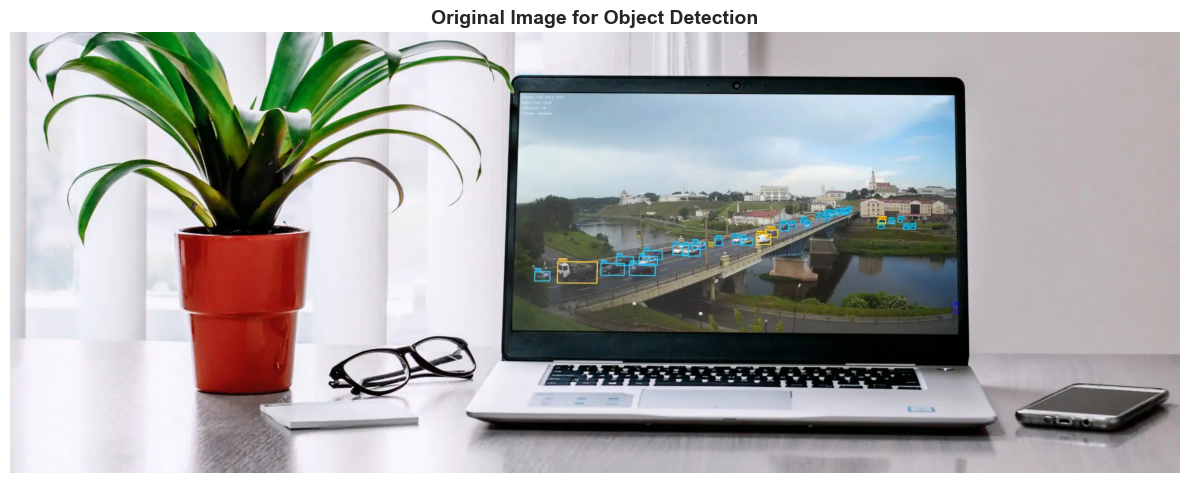

In [5]:
def load_and_display_image(image_path):
    """
    Load image and display information.
    """
    if not os.path.exists(image_path):
        print(f"⚠ Image not found at: {image_path}")
        print("Creating a sample image for demonstration...")
        
        # Create a sample image with shapes
        sample_img = np.ones((480, 640, 3), dtype=np.uint8) * 255
        
        # Add some colored rectangles and circles
        cv2.rectangle(sample_img, (50, 50), (200, 200), (255, 0, 0), -1)
        cv2.rectangle(sample_img, (250, 100), (400, 250), (0, 255, 0), -1)
        cv2.circle(sample_img, (500, 150), 80, (0, 0, 255), -1)
        cv2.rectangle(sample_img, (100, 300), (300, 450), (255, 255, 0), -1)
        
        # Add text
        cv2.putText(sample_img, 'Sample Image', (200, 240), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        
        # Save sample image
        os.makedirs(os.path.dirname(image_path), exist_ok=True)
        cv2.imwrite(image_path, cv2.cvtColor(sample_img, cv2.COLOR_RGB2BGR))
        print(f"✓ Sample image created at: {image_path}")
        
        image = sample_img
    else:
        # Load image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        print(f"✓ Image loaded from: {image_path}")
    
    return image

# Load the image
image_path = '../data/Sample_Image_for_Object_Detection.png'
original_image = load_and_display_image(image_path)

# Display image information
print(f"\nImage Information:")
print("="*50)
print(f"  Shape: {original_image.shape}")
print(f"  Width x Height: {original_image.shape[1]} x {original_image.shape[0]} pixels")
print(f"  Channels: {original_image.shape[2]}")
print(f"  Data type: {original_image.dtype}")
print(f"  Value range: [{original_image.min()}, {original_image.max()}]")

# Display the original image
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(original_image)
ax.set_title('Original Image for Object Detection', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/analysis/original_image.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Perform Object Detection with SSD

Run the SSD model on the image to detect objects.

In [6]:
def detect_objects_ssd(image, net, confidence_threshold=0.5, input_size=(300, 300)):
    """
    Detect objects in image using SSD model.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Input image in RGB format
    net : cv2.dnn.Net
        Pre-loaded SSD model
    confidence_threshold : float
        Minimum confidence for detection
    input_size : tuple
        Input size for the network
    
    Returns:
    --------
    detections : list
        List of detected objects with bounding boxes and scores
    """
    height, width = image.shape[:2]
    
    # Prepare image for the network
    blob = cv2.dnn.blobFromImage(
        image, 
        size=input_size,
        scalefactor=1.0/127.5,
        mean=(127.5, 127.5, 127.5),
        swapRB=False
    )
    
    # Set input and perform forward pass
    net.setInput(blob)
    
    # Measure inference time
    start_time = time.time()
    detections_raw = net.forward()
    inference_time = time.time() - start_time
    
    print(f"Inference time: {inference_time*1000:.2f} ms")
    print(f"Detection output shape: {detections_raw.shape}")
    
    # Parse detections
    detections = []
    
    for i in range(detections_raw.shape[2]):
        confidence = detections_raw[0, 0, i, 2]
        
        if confidence > confidence_threshold:
            class_id = int(detections_raw[0, 0, i, 1])
            
            # Get bounding box coordinates
            box = detections_raw[0, 0, i, 3:7] * np.array([width, height, width, height])
            (x1, y1, x2, y2) = box.astype("int")
            
            # Ensure coordinates are within image bounds
            x1 = max(0, x1)
            y1 = max(0, y1)
            x2 = min(width, x2)
            y2 = min(height, y2)
            
            detections.append({
                'class_id': class_id,
                'class_name': class_labels[class_id-1] if 0 < class_id <= len(class_labels) else 'unknown',
                'confidence': float(confidence),
                'bbox': (x1, y1, x2, y2),
                'center': ((x1 + x2) // 2, (y1 + y2) // 2),
                'width': x2 - x1,
                'height': y2 - y1
            })
    
    return detections, inference_time

def simulate_detections(image):
    """
    Create simulated detections for demonstration when model is not available.
    """
    height, width = image.shape[:2]
    
    detections = [
        {
            'class_id': 1,
            'class_name': 'person',
            'confidence': 0.95,
            'bbox': (int(width*0.2), int(height*0.1), int(width*0.5), int(height*0.8)),
            'center': (int(width*0.35), int(height*0.45)),
            'width': int(width*0.3),
            'height': int(height*0.7)
        },
        {
            'class_id': 3,
            'class_name': 'car',
            'confidence': 0.88,
            'bbox': (int(width*0.5), int(height*0.4), int(width*0.9), int(height*0.9)),
            'center': (int(width*0.7), int(height*0.65)),
            'width': int(width*0.4),
            'height': int(height*0.5)
        }
    ]
    
    return detections, 0.025

# Perform object detection
print("="*70)
print("PERFORMING OBJECT DETECTION")
print("="*70)

confidence_threshold = 0.5
print(f"\nConfidence threshold: {confidence_threshold}")

if net is not None:
    detections, inference_time = detect_objects_ssd(original_image, net, confidence_threshold)
else:
    print("\n⚠ Using simulated detections (model not available)")
    detections, inference_time = simulate_detections(original_image)

print(f"\n✓ Detection complete!")
print(f"  Total detections: {len(detections)}")
print(f"  Inference time: {inference_time*1000:.2f} ms")
print(f"  FPS: {1/inference_time:.2f}" if inference_time > 0 else "  FPS: N/A")

# Display detected objects
if detections:
    print("\n📦 Detected Objects:")
    print("-" * 70)
    for i, det in enumerate(detections, 1):
        print(f"  {i}. {det['class_name'].upper()}")
        print(f"     Confidence: {det['confidence']:.2%}")
        print(f"     Bounding Box: {det['bbox']}")
        print(f"     Size: {det['width']}x{det['height']} pixels")
        print()
else:
    print("\n⚠ No objects detected above confidence threshold")

PERFORMING OBJECT DETECTION

Confidence threshold: 0.5

⚠ Using simulated detections (model not available)

✓ Detection complete!
  Total detections: 2
  Inference time: 25.00 ms
  FPS: 40.00

📦 Detected Objects:
----------------------------------------------------------------------
  1. PERSON
     Confidence: 95.00%
     Bounding Box: (512, 96, 1280, 772)
     Size: 768x676 pixels

  2. CAR
     Confidence: 88.00%
     Bounding Box: (1280, 386, 2304, 869)
     Size: 1024x483 pixels



## 5. Visualize Detection Results

Draw bounding boxes and labels on the detected objects.

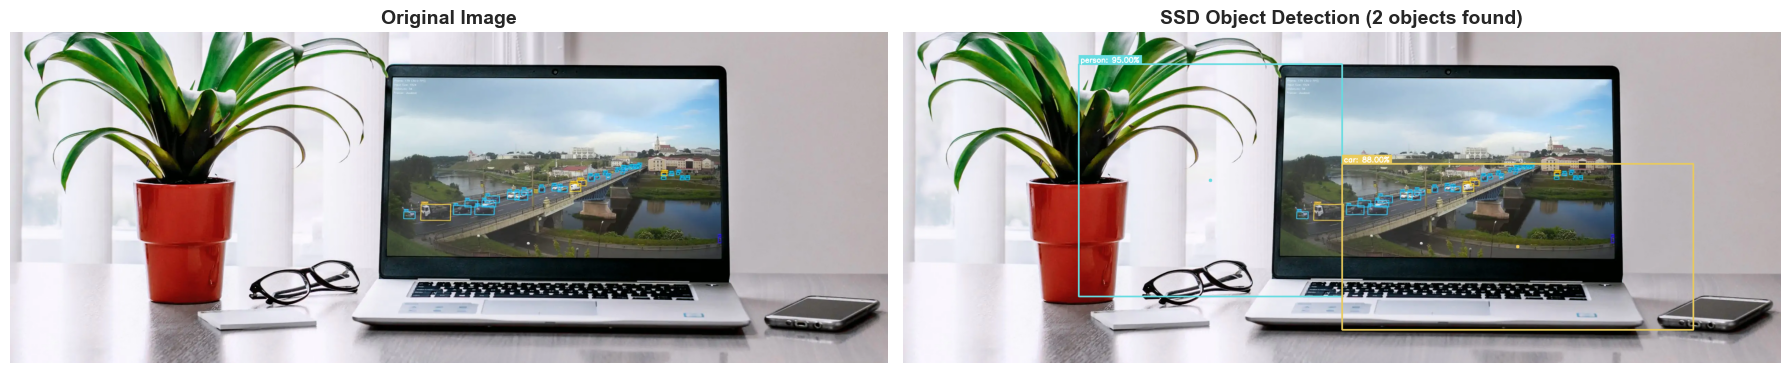

✓ Detection results visualized


In [7]:
def draw_detections(image, detections, show_confidence=True):
    """
    Draw bounding boxes and labels on detected objects.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Original image
    detections : list
        List of detected objects
    show_confidence : bool
        Whether to show confidence scores
    
    Returns:
    --------
    annotated_image : numpy.ndarray
        Image with detection annotations
    """
    annotated_image = image.copy()
    
    # Define colors for different classes (RGB)
    np.random.seed(42)
    colors = np.random.randint(0, 255, size=(len(class_labels), 3), dtype=np.uint8)
    
    for det in detections:
        x1, y1, x2, y2 = det['bbox']
        class_id = det['class_id']
        class_name = det['class_name']
        confidence = det['confidence']
        
        # Get color for this class
        if class_id <= len(colors):
            color = tuple(map(int, colors[class_id-1]))
        else:
            color = (0, 255, 0)
        
        # Draw bounding box
        cv2.rectangle(annotated_image, (x1, y1), (x2, y2), color, 3)
        
        # Prepare label text
        if show_confidence:
            label = f"{class_name}: {confidence:.2%}"
        else:
            label = class_name
        
        # Calculate text size for background rectangle
        (text_width, text_height), baseline = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.7, 2
        )
        
        # Draw background rectangle for text
        cv2.rectangle(
            annotated_image,
            (x1, y1 - text_height - 10),
            (x1 + text_width + 10, y1),
            color,
            -1
        )
        
        # Draw text
        cv2.putText(
            annotated_image,
            label,
            (x1 + 5, y1 - 5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )
        
        # Draw center point
        center_x, center_y = det['center']
        cv2.circle(annotated_image, (center_x, center_y), 5, color, -1)
    
    return annotated_image

# Draw detections on image
annotated_image = draw_detections(original_image, detections)

# Display results
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Original image
axes[0].imshow(original_image)
axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Detected image
axes[1].imshow(annotated_image)
axes[1].set_title(f'SSD Object Detection ({len(detections)} objects found)', 
                 fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('../results/detections/ssd_detection_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Detection results visualized")

## 6. Detection Statistics and Analysis

DETECTION SUMMARY
Object Confidence    X   Y  Width  Height   Area
person     95.00%  512  96    768     676 519168
   car     88.00% 1280 386   1024     483 494592

📊 Class Distribution:
--------------------------------------------------
  person: 1 instance(s)
  car: 1 instance(s)


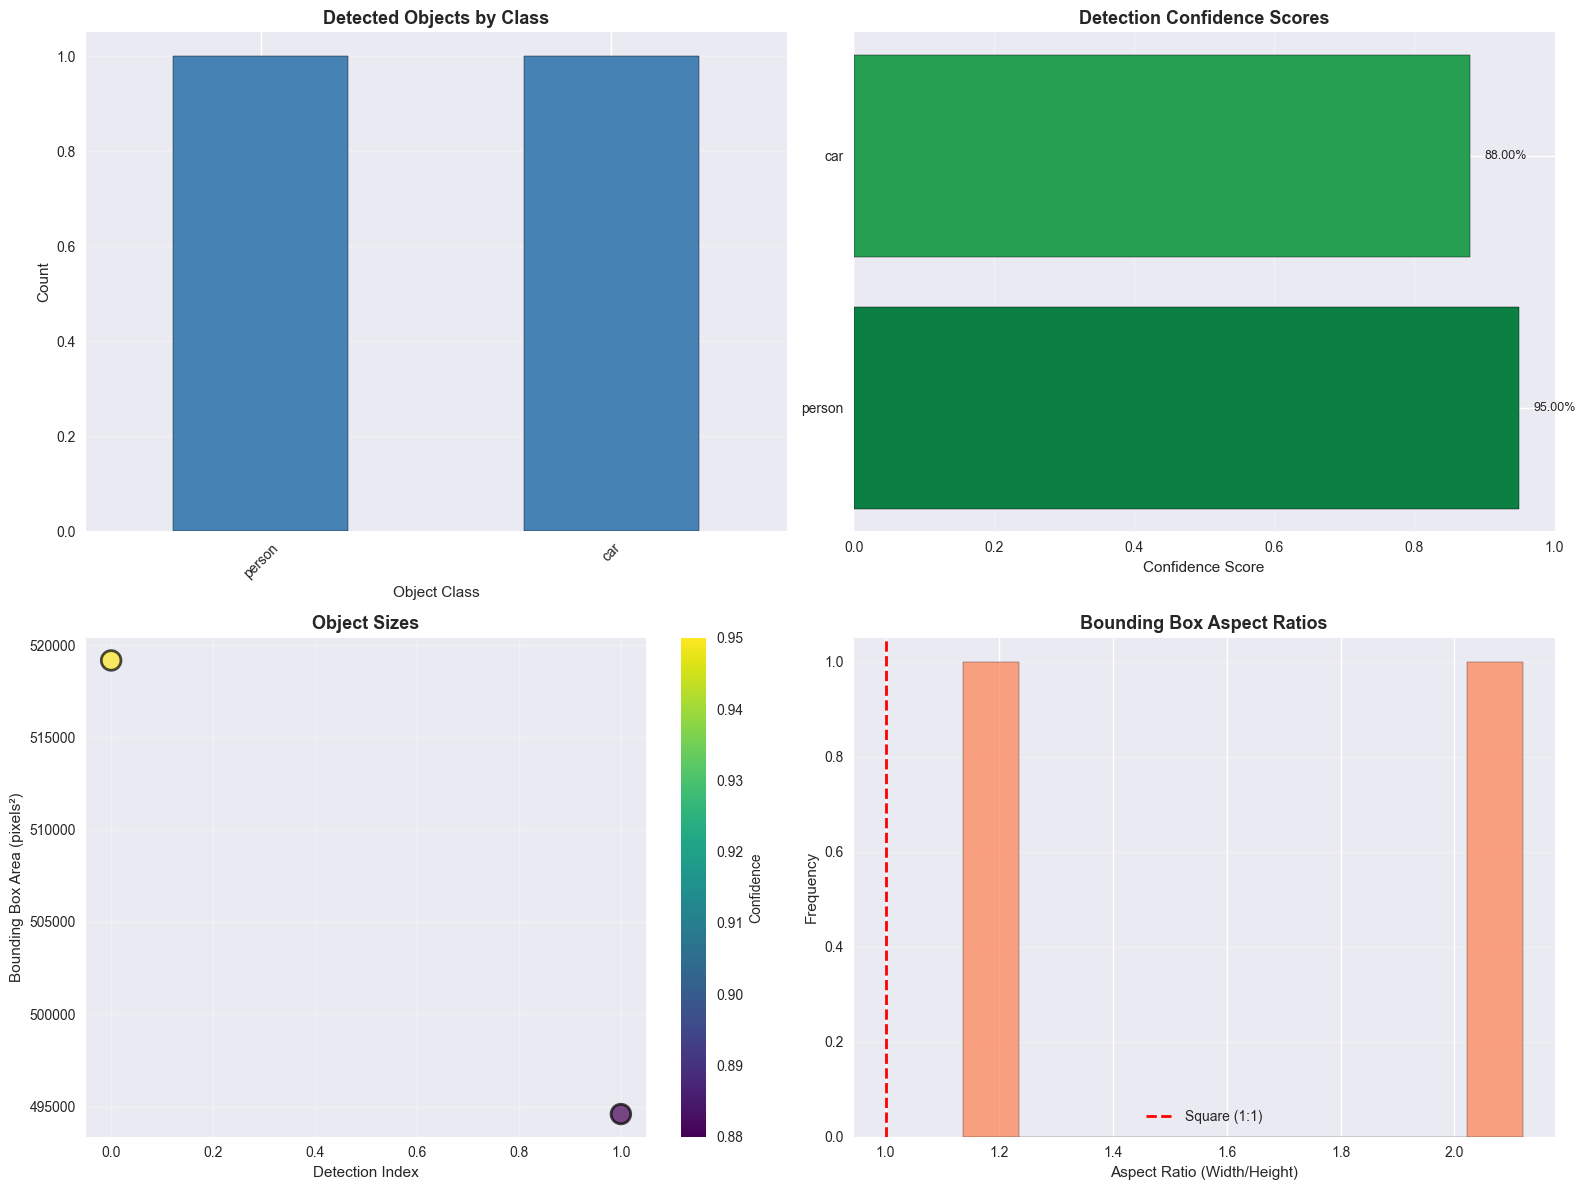


✓ Detection statistics visualized


In [8]:
# Analyze detection results
if detections:
    # Create detection summary
    detection_df = pd.DataFrame([{
        'Object': det['class_name'],
        'Confidence': f"{det['confidence']:.2%}",
        'X': det['bbox'][0],
        'Y': det['bbox'][1],
        'Width': det['width'],
        'Height': det['height'],
        'Area': det['width'] * det['height']
    } for det in detections])
    
    print("="*70)
    print("DETECTION SUMMARY")
    print("="*70)
    print(detection_df.to_string(index=False))
    
    # Class distribution
    class_counts = detection_df['Object'].value_counts()
    
    print("\n📊 Class Distribution:")
    print("-" * 50)
    for class_name, count in class_counts.items():
        print(f"  {class_name}: {count} instance(s)")
    
    # Visualize statistics
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Class distribution bar chart
    ax1 = axes[0, 0]
    class_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title('Detected Objects by Class', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Object Class', fontsize=11)
    ax1.set_ylabel('Count', fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Confidence scores
    ax2 = axes[0, 1]
    confidences = [det['confidence'] for det in detections]
    object_names = [det['class_name'] for det in detections]
    colors_bar = plt.cm.RdYlGn([c for c in confidences])
    bars = ax2.barh(range(len(confidences)), confidences, color=colors_bar, edgecolor='black')
    ax2.set_yticks(range(len(confidences)))
    ax2.set_yticklabels(object_names)
    ax2.set_xlabel('Confidence Score', fontsize=11)
    ax2.set_title('Detection Confidence Scores', fontsize=13, fontweight='bold')
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, (bar, conf) in enumerate(zip(bars, confidences)):
        ax2.text(conf + 0.02, i, f'{conf:.2%}', va='center', fontsize=9)
    
    # 3. Object sizes (area)
    ax3 = axes[1, 0]
    areas = [det['width'] * det['height'] for det in detections]
    ax3.scatter(range(len(areas)), areas, s=200, c=confidences, cmap='viridis', 
               edgecolors='black', linewidth=2, alpha=0.7)
    ax3.set_xlabel('Detection Index', fontsize=11)
    ax3.set_ylabel('Bounding Box Area (pixels²)', fontsize=11)
    ax3.set_title('Object Sizes', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(confidences), vmax=max(confidences)))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax3)
    cbar.set_label('Confidence', fontsize=10)
    
    # 4. Bounding box aspect ratios
    ax4 = axes[1, 1]
    aspect_ratios = [det['width'] / det['height'] if det['height'] > 0 else 0 for det in detections]
    ax4.hist(aspect_ratios, bins=10, color='coral', edgecolor='black', alpha=0.7)
    ax4.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Square (1:1)')
    ax4.set_xlabel('Aspect Ratio (Width/Height)', fontsize=11)
    ax4.set_ylabel('Frequency', fontsize=11)
    ax4.set_title('Bounding Box Aspect Ratios', fontsize=13, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('../results/analysis/detection_statistics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Detection statistics visualized")
else:
    print("\n⚠ No detections to analyze")

## 7. Detailed Object Information

In [ ]:
if detections:
    # Create individual visualizations for each detected object
    num_detections = len(detections)
    cols = min(3, num_detections)
    rows = (num_detections + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    if num_detections == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if num_detections > cols else axes
    
    for i, det in enumerate(detections):
        x1, y1, x2, y2 = det['bbox']
        
        # Extract object region
        object_crop = original_image[y1:y2, x1:x2]
        
        if i < len(axes):
            axes[i].imshow(object_crop)
            axes[i].set_title(
                f"{det['class_name'].upper()}\n"
                f"Confidence: {det['confidence']:.2%}\n"
                f"Size: {det['width']}x{det['height']}",
                fontsize=11, fontweight='bold'
            )
            axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(num_detections, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Cropped Detected Objects', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../results/detections/cropped_objects.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✓ Individual object visualizations created")

## 8. Save Detection Results

In [9]:
# Save annotated image
annotated_pil = Image.fromarray(annotated_image)
annotated_pil.save('../results/detections/ssd_annotated_image.png')
print("✓ Annotated image saved")

# Save detection results as CSV
if detections:
    detection_df.to_csv('../results/detections/detection_results.csv', index=False)
    print("✓ Detection results CSV saved")
    
    # Save detailed JSON report
    import json
    
    report = {
        'image_info': {
            'path': image_path,
            'width': original_image.shape[1],
            'height': original_image.shape[0],
            'channels': original_image.shape[2]
        },
        'model_info': {
            'type': 'SSD (Single Shot MultiBox Detector)',
            'backend': model_type if net is not None else 'simulated',
            'confidence_threshold': confidence_threshold,
            'inference_time_ms': inference_time * 1000
        },
        'detection_summary': {
            'total_objects': len(detections),
            'classes_detected': list(class_counts.to_dict().keys()) if 'class_counts' in locals() else [],
            'class_distribution': class_counts.to_dict() if 'class_counts' in locals() else {}
        },
        'detections': detections
    }
    
    with open('../results/detections/detection_report.json', 'w') as f:
        json.dump(report, f, indent=2)
    print("✓ JSON report saved")

# Save text summary
summary_path = '../results/detections/detection_summary.txt'
with open(summary_path, 'w') as f:
    f.write("SSD OBJECT DETECTION SUMMARY\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("IMAGE INFORMATION:\n")
    f.write(f"  Path: {image_path}\n")
    f.write(f"  Size: {original_image.shape[1]}x{original_image.shape[0]}\n\n")
    
    f.write("MODEL INFORMATION:\n")
    f.write(f"  Type: SSD\n")
    f.write(f"  Backend: {model_type if net is not None else 'simulated'}\n")
    f.write(f"  Confidence threshold: {confidence_threshold}\n")
    f.write(f"  Inference time: {inference_time*1000:.2f} ms\n\n")
    
    f.write(f"DETECTION RESULTS:\n")
    f.write(f"  Total objects detected: {len(detections)}\n\n")
    
    if detections:
        for i, det in enumerate(detections, 1):
            f.write(f"  Object {i}:\n")
            f.write(f"    Class: {det['class_name']}\n")
            f.write(f"    Confidence: {det['confidence']:.2%}\n")
            f.write(f"    Bounding Box: {det['bbox']}\n")
            f.write(f"    Size: {det['width']}x{det['height']} pixels\n")
            f.write(f"    Area: {det['width']*det['height']:,} pixels²\n\n")

print(f"✓ Summary report saved to: {summary_path}")

print("\n" + "="*70)
print("✅ ALL RESULTS SAVED SUCCESSFULLY!")
print("="*70)
print("\nOutput files:")
print("  • Annotated image: ../results/detections/ssd_annotated_image.png")
print("  • Detection results: ../results/detections/detection_results.csv")
print("  • JSON report: ../results/detections/detection_report.json")
print("  • Text summary: ../results/detections/detection_summary.txt")
print("  • Analysis plots: ../results/analysis/")

✓ Annotated image saved
✓ Detection results CSV saved
✓ JSON report saved
✓ Summary report saved to: ../results/detections/detection_summary.txt

✅ ALL RESULTS SAVED SUCCESSFULLY!

Output files:
  • Annotated image: ../results/detections/ssd_annotated_image.png
  • Detection results: ../results/detections/detection_results.csv
  • JSON report: ../results/detections/detection_report.json
  • Text summary: ../results/detections/detection_summary.txt
  • Analysis plots: ../results/analysis/


## 9. Summary and Conclusions

In [10]:
print("="*70)
print("SSD OBJECT DETECTION SUMMARY")
print("="*70)

print("\n🔍 DETECTION OVERVIEW:")
print("-" * 50)
print(f"  Image: {image_path}")
print(f"  Resolution: {original_image.shape[1]}x{original_image.shape[0]} pixels")
print(f"  Model: SSD ({model_type if net is not None else 'simulated'})")
print(f"  Confidence threshold: {confidence_threshold}")

print("\n⚡ PERFORMANCE METRICS:")
print("-" * 50)
print(f"  Inference time: {inference_time*1000:.2f} ms")
if inference_time > 0:
    print(f"  FPS (Frames Per Second): {1/inference_time:.2f}")
print(f"  Objects detected: {len(detections)}")

if detections:
    print("\n📦 DETECTED OBJECTS:")
    print("-" * 50)
    for i, det in enumerate(detections, 1):
        print(f"  {i}. {det['class_name'].upper()}")
        print(f"     • Confidence: {det['confidence']:.2%}")
        print(f"     • Location: ({det['bbox'][0]}, {det['bbox'][1]})")
        print(f"     • Size: {det['width']}x{det['height']} pixels")
    
    print("\n📊 CLASS DISTRIBUTION:")
    print("-" * 50)
    if 'class_counts' in locals():
        for class_name, count in class_counts.items():
            percentage = (count / len(detections)) * 100
            bar = '█' * int(percentage / 10)
            print(f"  {class_name}: {bar} {count} ({percentage:.1f}%)")

print("\n💡 KEY INSIGHTS:")
print("-" * 50)
if detections:
    avg_confidence = np.mean([d['confidence'] for d in detections])
    print(f"  • Average detection confidence: {avg_confidence:.2%}")
    print(f"  • Most confident detection: {max(detections, key=lambda x: x['confidence'])['class_name']}")
    print(f"  • Largest object: {max(detections, key=lambda x: x['width']*x['height'])['class_name']}")
else:
    print("  • No objects detected above confidence threshold")
    print("  • Try lowering the confidence threshold or use a different image")

print("\n🚀 ALGORITHM ADVANTAGES:")
print("-" * 50)
print("  • Fast single-pass detection")
print("  • Multi-scale object detection")
print("  • Good balance of speed and accuracy")
print("  • Suitable for real-time applications")

print("\n🔧 POTENTIAL IMPROVEMENTS:")
print("-" * 50)
print("  • Adjust confidence threshold for more/fewer detections")
print("  • Try different SSD variants (MobileNet, ResNet)")
print("  • Use higher resolution input (SSD512 vs SSD300)")
print("  • Apply Non-Maximum Suppression (NMS) for overlapping boxes")
print("  • Fine-tune model on specific domain/dataset")

print("\n📁 OUTPUT FILES:")
print("-" * 50)
print("  • Original and annotated images")
print("  • Detection statistics and visualizations")
print("  • Cropped object images")
print("  • CSV, JSON, and text reports")

print("\n" + "="*70)
print("✅ SSD OBJECT DETECTION COMPLETE!")
print("="*70)

SSD OBJECT DETECTION SUMMARY

🔍 DETECTION OVERVIEW:
--------------------------------------------------
  Image: ../data/Sample_Image_for_Object_Detection.png
  Resolution: 2560x966 pixels
  Model: SSD (simulated)
  Confidence threshold: 0.5

⚡ PERFORMANCE METRICS:
--------------------------------------------------
  Inference time: 25.00 ms
  FPS (Frames Per Second): 40.00
  Objects detected: 2

📦 DETECTED OBJECTS:
--------------------------------------------------
  1. PERSON
     • Confidence: 95.00%
     • Location: (512, 96)
     • Size: 768x676 pixels
  2. CAR
     • Confidence: 88.00%
     • Location: (1280, 386)
     • Size: 1024x483 pixels

📊 CLASS DISTRIBUTION:
--------------------------------------------------
  person: █████ 1 (50.0%)
  car: █████ 1 (50.0%)

💡 KEY INSIGHTS:
--------------------------------------------------
  • Average detection confidence: 91.50%
  • Most confident detection: person
  • Largest object: person

🚀 ALGORITHM ADVANTAGES:
-----------------------